In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [4]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2025-01-01,Male,41,Beauty,5,1000,5000
1,2025-01-02,Female,28,Home Decor,3,1000,3000
2,2025-01-03,Male,25,Beauty,3,1500,4500
3,2025-01-04,Male,53,Electronics,5,500,2500
4,2025-01-05,Male,55,Home Decor,4,1000,4000


In [5]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              200 non-null    object
 1   Gender            200 non-null    object
 2   Age               200 non-null    int64 
 3   Product Category  200 non-null    object
 4   Quantity          200 non-null    int64 
 5   Price per Unit    200 non-null    int64 
 6   Total Amount      200 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 11.1+ KB
None
              Age   Quantity  Price per Unit  Total Amount
count  200.000000  200.00000      200.000000    200.000000
mean    40.000000    3.12000      677.000000   2112.250000
std     11.728503    1.47188      487.528894   1932.462027
min     18.000000    1.00000      100.000000    100.000000
25%     31.000000    2.00000      250.000000    500.000000
50%     41.500000    3.00000      500.000000   1500.000000
75%     50.00

In [6]:

df.drop_duplicates(inplace=True)
df.isnull().sum()

,0
Date,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

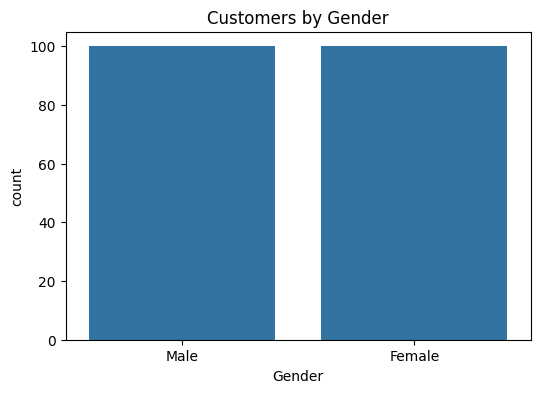

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Customers by Gender")
plt.show()

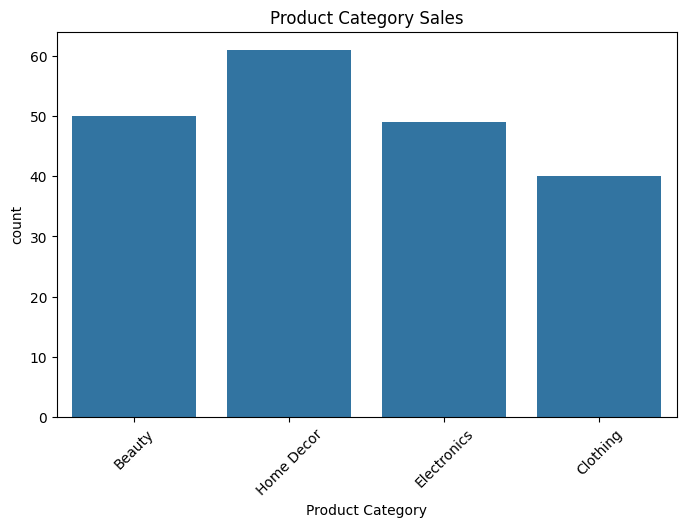

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Product Category', data=df)
plt.xticks(rotation=45)
plt.title("Product Category Sales")
plt.show()

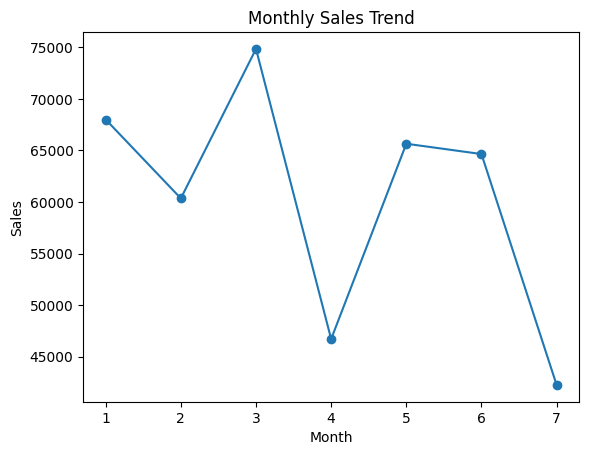

In [10]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

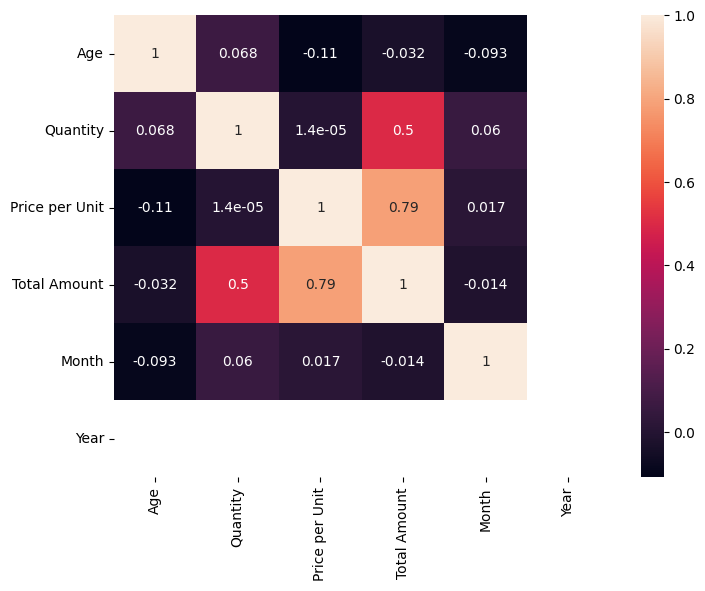

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True
)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [13]:
X = df[['Age','Quantity','Price per Unit']]
y = df['Total Amount']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
pred = model.predict(X_test)

print(pred[:5])

[ 722.97943092 4375.50065485 4326.57121819 1979.18197981 1463.60429642]


In [17]:
print("MAE:",mean_absolute_error(y_test,pred))

print("R2 Score:",r2_score(y_test,pred))

MAE: 438.5346163101922
R2 Score: 0.8980870236952346


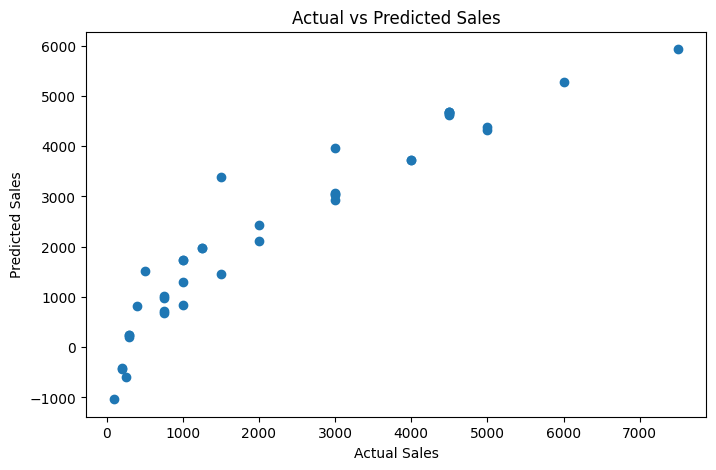

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()